In [1]:
class Node:
    def __init__(self, data):
        self.data = data
        self.left = None
        self.right = None

In [102]:
class BinaryTree:
    def __init__(self):
        self.root = None

    def find(self, data):
        return self._find(self.root, data)

    def _find(self, node, data, cnt=0):
        cnt += 1
        if node is None:
            return None, cnt
        if node.data == data:
            return node, cnt
        elif node.data > data:
            return self._find(node.left, data, cnt)
        else:
            return self._find(node.right, data, cnt)

    def add(self, data):
        curnode = self.root
        while curnode is not None:
            if data < curnode.data:
                if curnode.left:
                    curnode = curnode.left
                else:
                    curnode.left = Node(data)
                    return
            elif data > curnode.data:
                if curnode.right:
                    curnode = curnode.right
                else:
                    curnode.right = Node(data)
                    return               
        self.root = Node(data)

    def add_rec(self, data):
        if self.root:
            self._add_rec(data, self.root)
        else:
            self.root = Node(data)

    def _add_rec(self, data, node):
        if data < node.data:
            if node.left:
                self._add_rec(data, node.left)
            else:
                node.left = Node(data)
                return
        else:
            if node.right:
                self._add_rec(data, node.right)
            else:
                node.right = Node(data)
                return
        

    def print(self):
        if self.root:
            stack = [self.root]
            while len(stack):
                curnode = stack.pop(0)
                print(curnode.data)
                if curnode.left is not None:
                    stack.append(curnode.left)
                if curnode.right is not None:
                    stack.append(curnode.right)

    def print_rec(self, num, node):
        if node:
            self.print_rec(num + 1, node.right)
            print("  "*num, node.data)
            self.print_rec(num +1, node.left)

    def print_rec_wide(self, nodes):
        if len(nodes) != 0:
            node = nodes.pop(0)
            if node:
                print(node.data)
                if node.left:
                    nodes.append(node.left)
                if node.right:
                    nodes.append(node.right)
            self.print_rec_wide(nodes)
    
    def height(self, node):
        if node:
            return max(self.height(node.left),self.height(node.right)) + 1
        return 0

    def is_balanced(self, node):
        if node:
            hl = self.height(node.left)
            hr = self.height(node.right)
            if abs(hl - hr) > 1:
                return False, hl-hr
            bl, dl = self.is_balanced(node.left)
            br, dr = self.is_balanced(node.right)
            return bl and br, max(dl, dr)
        return True, 0

    def balance(self):
        if self.root:
            self.root = self._balance(self.root)

    def rotation(self, node, direction):
        if direction == 'left':
            node_to_return = node.right
            node.right = node_to_return.left
            node_to_return.left = node
            return node_to_return
        else:
            node_to_return = node.left
            node.left = node_to_return.right
            node_to_return.right = node
            return node_to_return

    def _balance(self, node):
        if node:
            node.left = self._balance(node.left)
            node.right = self._balance(node.right)

            hl = self.height(node.left)
            hr = self.height(node.right)
            if hl - hr > 1:
                if self.height(node.left.right)>self.height(node.left.left):
                    node.left = self.rotation(node.left, 'left')
                node = self.rotation(node, 'right')
            elif hl - hr < -1:
                if self.height(node.right.left)>self.height(node.right.right):
                    node.right = self.rotation(node.right, 'right')
                node = self.rotation(node, 'left')
        return node
        
        


In [103]:
tree = BinaryTree()
tree.add(10)
tree.add(20)
tree.add(30)
tree.add(4)
tree.add(1)
tree.add(40)

tree.balance()
tree.print_rec(0, tree.root)

     40
   30
     20
 10
   4
     1


In [104]:
tree.find(30)

(<__main__.Node at 0x111299550>, 2)

In [108]:
import numpy as np
import time


lens = [10, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]
cnts_binary_bal = []
times_binary = []
for l in lens:
    cnts_binary_tmp = []
    times_binary_tmp = []
    for i in range(10):
        tree = BinaryTree()
        elems = set()
        while len(elems) < l:
            val = np.random.randint(0, l*2, 1)[0]
            if val not in elems:
                elems.add(val)
                tree.add(val)
        val = np.random.randint(0, l*2, 1)
        tree.balance()
        start = time.time()
        _, cnt1 = tree.find(val)
        times_binary_tmp.append(time.time() - start)
        cnts_binary_tmp.append(cnt1)
    cnts_binary_bal.append(np.mean(cnts_binary_tmp))
    times_binary.append(np.mean(times_binary_tmp))

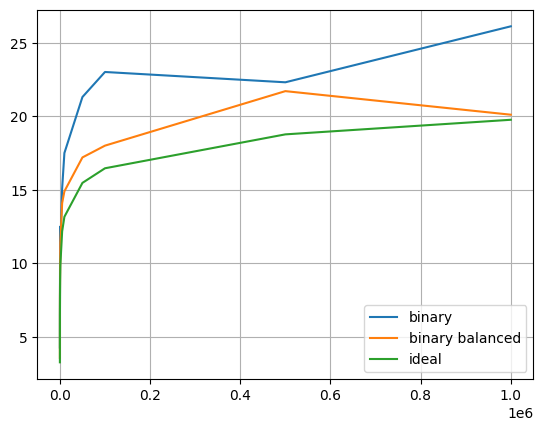

In [109]:
from matplotlib import pyplot as plt

plt.plot(lens, cnts_binary, label='binary')
plt.plot(lens, cnts_binary_bal, label='binary balanced')
plt.plot(lens, 1.43*np.log(lens), label='ideal')
plt.legend()
plt.grid()

In [49]:
tree.root

In [31]:
tree = BinaryTree()
tree.is_balanced(tree.root)

(True, 0)

In [33]:
tree.add_rec(10)
tree.is_balanced(tree.root)

(True, 0)

In [34]:
tree.add_rec(20)
tree.add_rec(15)
tree.add_rec(30)
tree.add_rec(5)
tree.add_rec(8)
tree.add_rec(3)
tree.add_rec(1)
tree.add_rec(4)

In [27]:
tree.print()

10
5
20
3
8
15
30
1
4


In [35]:
tree.print_rec(0, tree.root)

     30
   20
     15
 10
     8
   5
       4
     3
       1


In [36]:
tree.is_balanced(tree.root)

(True, 0)

In [38]:
tree = BinaryTree()
tree.add_rec(20)
tree.add_rec(30)
tree.add_rec(40)
tree.add_rec(50)
tree.is_balanced(tree.root)

(False, -3)